In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import joblib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import (
    GridSearchCV,
    learning_curve,
    train_test_split
)

from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso


from catboost import CatBoostRegressor

from transformers.transformers import *

In [3]:
data = pd.read_csv('../data/laptop_data.csv')

X = data.drop(columns=['Price', 'Unnamed: 0'])
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [4]:
feature_engineering = ColumnTransformer(
    transformers=[
    ('company', CompanyBinning(), ['Company']),
    ('typename', TypeNameEncoder(), ['TypeName']),
    ('inches', InchesBinning(), ['Inches']),
    ('screen', ScreenResolutionEncoder(), ['ScreenResolution']),
    ('cpu', CpuEncoder(), ['Cpu']),
    ('ram', RamBinning(), ['Ram']),
    ('memory', MemoryEncoder(), ['Memory']),
    ('gpu', GpuEncoder(), ['Gpu']),
    ('opsys', OpSysEncoder(), ['OpSys']),
    ('weight', WeightExtract(), ['Weight'])
], remainder='drop')

In [5]:
catboost_fs = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=3,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=0
)
feature_selector = SelectFromModel(catboost_fs, threshold='median')

In [6]:
preprocess = Pipeline([
    ('feature_eng', feature_engineering),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

pipeline_fs = Pipeline([
    ('preprocess', preprocess),
    ('feature_selection', feature_selector),
    ('model', Lasso(max_iter=50000))
])

param_grid = {
    'model__alpha': [1, 20, 50, 100],
}

grid = GridSearchCV(
    pipeline_fs,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=50000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [1, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate param

In [7]:
print("Best R²:", grid.best_score_)

Best R²: 0.7965068534177077


In [8]:
train_sizes, train_scores, val_scores = learning_curve(
    grid.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

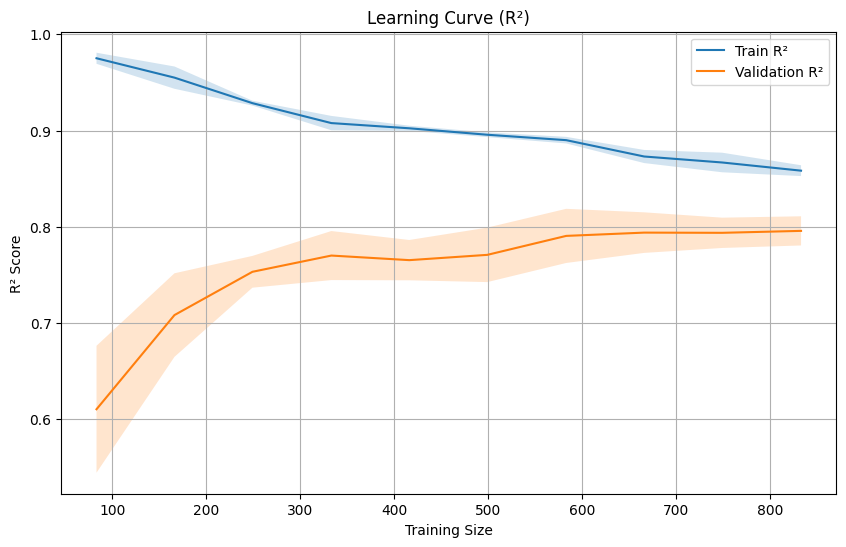

In [9]:
plt.figure(figsize=(10,6))

plt.plot(train_sizes, train_mean, label='Train R²')
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(train_sizes, val_mean, label='Validation R²')
plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel("Training Size")
plt.ylabel("R² Score")
plt.title("Learning Curve (R²)")
plt.legend()
plt.grid(True)
output_path ="../outputs/figures/learning_curve.png"
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

In [10]:
joblib.dump(grid.best_estimator_, "../outputs/models/laptop_price_lasso_model.pkl")
print("Model saved as laptop_price_lasso_model.pkl")

Model saved as laptop_price_lasso_model.pkl
